In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

b = np.load('rmd17_benzene.npz')
print(b.files)
b['coords']
print(b['nuclear_charges'])

a = np.load('rmd17_ethanol.npz')
print(a['nuclear_charges'])


['nuclear_charges', 'coords', 'energies', 'forces', 'old_indices', 'old_energies', 'old_forces']
[6 6 6 6 6 6 1 1 1 1 1 1]
[6 6 8 1 1 1 1 1 1]


In [ ]:
all_coords = b['coords']
all_energies = b['energies']

print(all_coords.shape)
print(all_energies.shape)

N = len(all_coords)
#np.random.seed(42)  
perm = np.random.permutation(N)

coords = all_coords[perm[:2000]]        
energies = all_energies[perm[:2000]]

print(coords.shape)
print(energies.shape)


(100000, 12, 3)
(100000,)
(2000, 12, 3)
(2000,)


In [3]:
bonds = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(0,6),(1,7),(2,8),(3,9),(4,10),(5,11)]

def bond_lengths(coords):
    lengths = []
    for i in range(len(coords)):
        for a,b in bonds:
            length = np.linalg.norm(coords[i,a,:]-coords[i,b,:])

            lengths.append(length)
    return(lengths)

ben_lengths = np.array(bond_lengths(coords))
BL = ben_lengths.reshape(len(coords), len(bonds))
print(BL)
print(BL.shape)

[[1.38467216 1.44333988 1.3872516  ... 1.06964714 1.04086262 1.09107516]
 [1.39050854 1.39503297 1.41553559 ... 1.08540591 1.13275681 1.09571073]
 [1.39051559 1.45034003 1.43644018 ... 1.1232137  1.10467843 1.06245625]
 ...
 [1.39976667 1.42069375 1.40376202 ... 1.12715431 1.11139014 1.04280085]
 [1.44073801 1.42160051 1.4374453  ... 1.07248357 1.0874769  1.06168404]
 [1.40641217 1.39181469 1.42053157 ... 1.08733301 1.1137697  1.09455703]]
(2000, 12)


In [4]:
ccc = [((c-1) % 6, c, (c+1) % 6) for c in range(6)]
hcc = [(6 + c, c, (c+1) % 6) for c in range(6)]
cch = [((c-1) % 6, c, 6 + c) for c in range(6)]

angles = ccc + hcc + cch

def bond_angles(coords):
    ben_angles = []
    for o in range(len(coords)):
        for i,j,k in angles:
            length1 = np.linalg.norm(coords[o,i,:]-coords[o,j,:])
            length2 = np.linalg.norm(coords[o,k,:]-coords[o,j,:])

            dot_prod = np.dot((coords[o,i,:]-coords[o,j,:]),(coords[o,k,:]-coords[o,j,:]))

            cosang = dot_prod / (length1 * length2)

            ben_angles.append(np.acos(cosang))
    return(ben_angles)

benz_angles = np.array(bond_angles(coords))
AN = benz_angles.reshape(len(coords), len(angles))
print(AN)
print(AN.shape)


[[2.092813   2.05304678 2.10397655 ... 2.05746879 2.0808618  2.1532578 ]
 [2.10740141 2.06407249 2.07781707 ... 2.05094111 2.08352882 2.13582838]
 [2.09745078 2.14556043 2.0033534  ... 2.18207045 1.97953094 1.99182482]
 ...
 [2.10146435 2.07742202 2.11820129 ... 2.17547216 2.04657082 2.07520781]
 [2.0619684  2.06355838 2.17825449 ... 2.08274703 1.98732974 2.14876265]
 [2.077251   2.06870325 2.12053723 ... 2.15651143 2.13731766 2.06958381]]
(2000, 18)


In [5]:
X = np.concatenate((BL,AN), axis=1)
y = np.array(energies)

print(X)
print(y)
print(X.shape)
print(y.shape)

[[1.38467216 1.44333988 1.3872516  ... 2.05746879 2.0808618  2.1532578 ]
 [1.39050854 1.39503297 1.41553559 ... 2.05094111 2.08352882 2.13582838]
 [1.39051559 1.45034003 1.43644018 ... 2.18207045 1.97953094 1.99182482]
 ...
 [1.39976667 1.42069375 1.40376202 ... 2.17547216 2.04657082 2.07520781]
 [1.44073801 1.42160051 1.4374453  ... 2.08274703 1.98732974 2.14876265]
 [1.40641217 1.39181469 1.42053157 ... 2.15651143 2.13731766 2.06958381]]
[-145432.44919802 -145431.08656484 -145429.58330585 ... -145428.98207879
 -145431.41269247 -145429.40142844]
(2000, 30)
(2000,)


In [6]:
mu_X = X.mean(axis=0)
std_X = X.std(axis=0)

X_new = (X - mu_X)/ std_X

mu_y = y.mean()
std_y = y.std()

y_new = (y - mu_y)/ std_y

print(y_new)

[-0.47731686  0.08474071  0.70480347 ...  0.952797   -0.04978009
  0.77982408]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2)

In [8]:
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

print(y_train_t.shape)

torch.Size([1600, 1])


In [9]:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [10]:
import torch.nn as nn

In [11]:
class Model(nn.Module):
    
    def __init__(self, input_features = 30, hidden1 = 64, hidden2 = 32, hidden3 = 16, output_features = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden1) 
        self.fc2 = nn.Linear(hidden1, hidden2) 
        self.fc3 = nn.Linear(hidden2, hidden3) 
        self.fc4 = nn.Linear(hidden3, output_features)
        self.ac1 = nn.SiLU()
        self.ac2 = nn.SiLU()
        self.ac3 = nn.SiLU()

    def forward(self, x):
        x = self.fc1(x) 
        x = self.ac1(x)
        x = self.fc2(x)
        x = self.ac2(x) 
        x = self.fc3(x)
        x = self.ac3(x)
        x = self.fc4(x) 
        return x

In [12]:
epochs = 200
losses = []

model = Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)

for epoch in range(epochs):

    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    scheduler.step()
    
    if epoch%10==0:
        print(f'Epoch: {epoch} and loss: {loss}') 
    

Epoch: 0 and loss: 0.8633967041969299
Epoch: 10 and loss: 0.11461809277534485
Epoch: 20 and loss: 0.14161807298660278
Epoch: 30 and loss: 0.06881067156791687
Epoch: 40 and loss: 0.067536860704422
Epoch: 50 and loss: 0.0907847136259079
Epoch: 60 and loss: 0.06970162689685822
Epoch: 70 and loss: 0.06445610523223877
Epoch: 80 and loss: 0.060827501118183136
Epoch: 90 and loss: 0.051369886845350266
Epoch: 100 and loss: 0.04803919792175293
Epoch: 110 and loss: 0.045485567301511765
Epoch: 120 and loss: 0.06554622203111649
Epoch: 130 and loss: 0.05044739693403244
Epoch: 140 and loss: 0.04542842507362366
Epoch: 150 and loss: 0.059256259351968765
Epoch: 160 and loss: 0.0314330980181694
Epoch: 170 and loss: 0.03193242847919464
Epoch: 180 and loss: 0.027987824752926826
Epoch: 190 and loss: 0.04204746335744858


C:\Users\home\AppData\Local\Temp\ipykernel_36140\2564702601.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


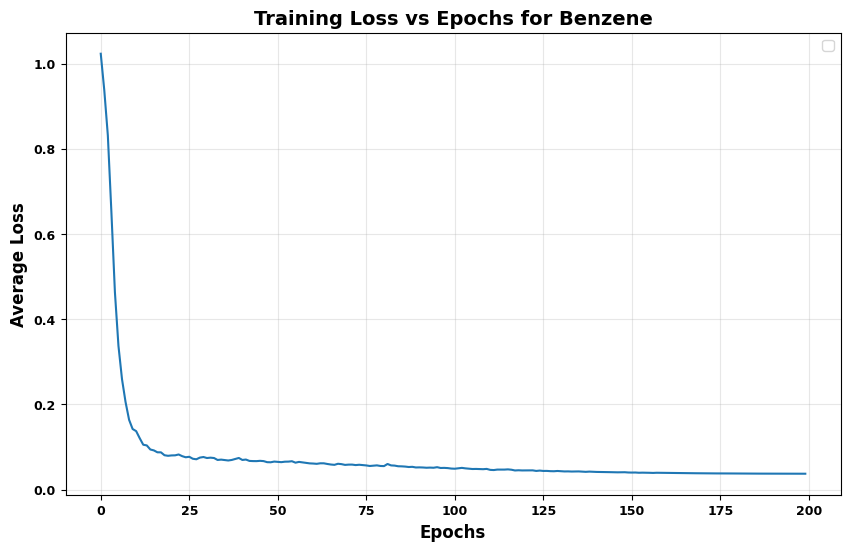

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), losses)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Average Loss', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig('REALTrain_loss_vs_epoch_benzene.png')
plt.title('Training Loss vs Epochs for Benzene', fontsize=14, fontweight='bold')
plt.show()

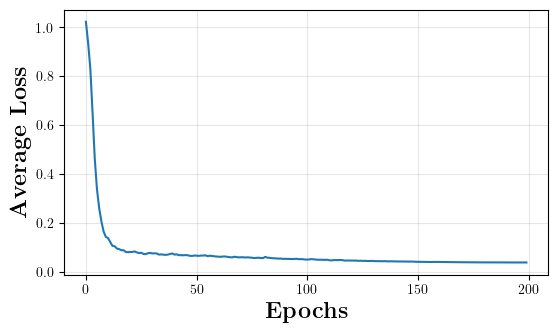

In [ ]:
import matplotlib as mpl

mpl.rcParams.update({"text.usetex": True, "font.family": "serif", "font.serif": ["Computer Modern"], "axes.labelsize": 17,
    "font.size": 17, "legend.fontsize": 13, "xtick.labelsize": 13, "ytick.labelsize": 13})

def set_size(width_pt, fraction=1):
    inches_per_pt = 1/72.27
    golden_ratio = (5**0.5 - 1)/2
    width_in = width_pt * inches_per_pt * fraction
    height_in = width_in * golden_ratio
    return (width_in, height_in)

fig = plt.figure(figsize=set_size(426))

plt.plot(losses, label='Training Loss')
plt.xlabel(r'\textbf{Epochs}')
plt.ylabel(r'\textbf{Average Loss}')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('NN_Benzene_Loss.pdf')
plt.show()

In [15]:
model.eval()
with torch.no_grad():
    final_test_pred = model(X_test_t)
    final_test_loss = nn.MSELoss()
    loss = final_test_loss(final_test_pred, y_test_t)
print("final test loss:", float(loss))

pred_unnormalized = final_test_pred.numpy().squeeze() * std_y + mu_y
true_unnormalized = y_test_t.numpy().squeeze() * std_y + mu_y

final test loss: 0.09445294737815857


In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(true_unnormalized, pred_unnormalized)
mae = mean_absolute_error(true_unnormalized, pred_unnormalized)
mse = mean_squared_error(true_unnormalized, pred_unnormalized)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")  
print(f"MAE: {mae:.4f}")      
print(f"RMSE: {rmse:.4f}")

R² Score: 0.8996
MAE: 0.5872
RMSE: 0.7451


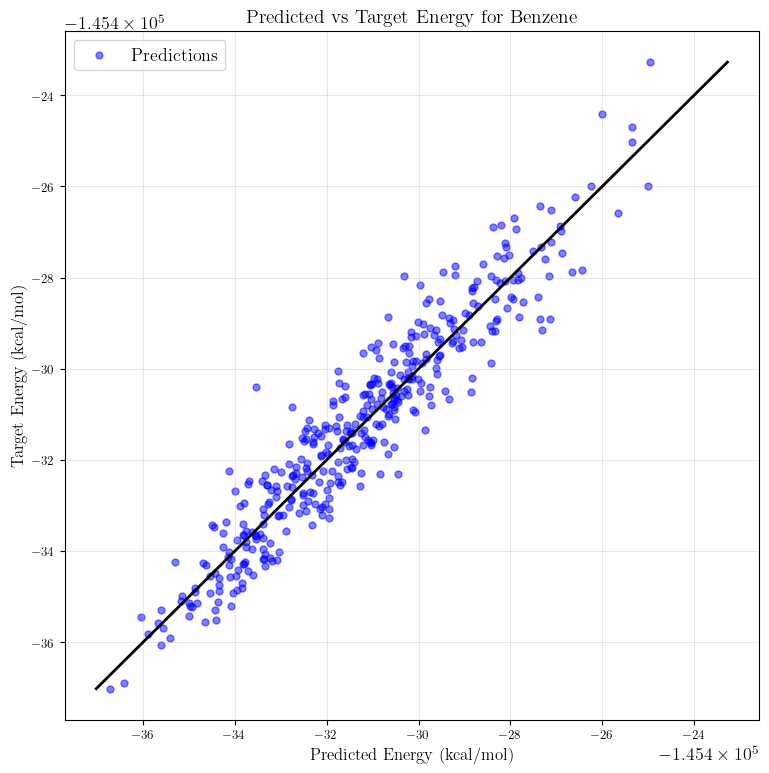

In [17]:
plt.figure(figsize=(8,8))
plt.scatter(pred_unnormalized, true_unnormalized, alpha=0.5, s=25, color='blue', label='Predictions')
plt.plot([true_unnormalized.min(), true_unnormalized.max()], 
         [true_unnormalized.min(), true_unnormalized.max()], 
         'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Predicted Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.ylabel('Target Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.tight_layout()
#plt.savefig('REALtarget_vs_predE_benzene.png')
plt.title('Predicted vs Target Energy for Benzene', fontsize=14, fontweight='bold')
plt.show()

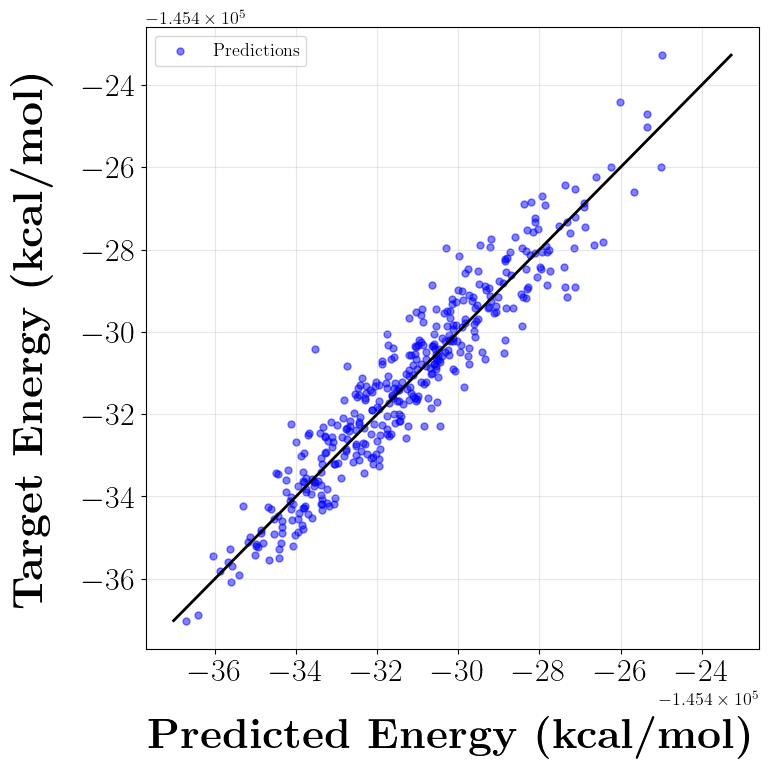

: 

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(pred_unnormalized, true_unnormalized, alpha=0.5, s=25, color='blue', label='Predictions')
plt.plot([true_unnormalized.min(), true_unnormalized.max()], [true_unnormalized.min(), true_unnormalized.max()],'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel(r'\textbf{Predicted Energy (kcal/mol)}', fontsize=31, labelpad=21)
plt.ylabel(r'\textbf{Target Energy (kcal/mol)}', fontsize=31, labelpad=21)
plt.xticks(fontsize=23)
plt.yticks(fontsize=23)
plt.tight_layout()
#plt.savefig('NN_Benzene_Scatter.pdf', bbox_inches='tight')
plt.show()